# Bodrum Hotel & Destination Intelligence
## 08 - Destination Intelligence Analysis

Bu notebook 14 Bodrum destinasyonunu tek bir ortalama puana indirgemeden; **arz, resmî eşleşme
kapasitesi, müşteri memnuniyeti, popülerlik, fiyat konumu, doğrulanmış lüks arz, değer sinyali ve
mevcut resmî destinasyon bağlamları** üzerinden inceler.

Temel kapsam ilkesi:

> Resmî yıldız/oda/yatak göstergeleri yalnızca 07 aşamasındaki yüksek güvenli proje-otel
> eşleşmelerini temsil eder. Eşleşmeyen alanlarda sıfır “gerçek kapasite” varsayılmaz; kapasite
> bilinmiyor (`NaN`) olarak korunur.

Restoran, bar, gece hayatı, plaj, Blue Flag, yürünebilirlik, havalimanı süresi, POI yoğunluğu,
erişilebilirlik, koordinat veya alan merkezi üretilmez. Harita, kümeleme, tahmin, anomali modeli,
NLP, sentiment ve öneri sistemi bu notebookun kapsamı dışındadır.


### 1. Kurulum, yollar ve kaynak bütünlüğü

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.destination_intelligence import (
    EXPECTED_AREAS,
    add_quadrants,
    add_subindices,
    build_archetypes,
    build_destination_master,
    input_consistency_check,
    spearman_correlations,
    validate_area_set,
    value_sensitivity,
)

HOTELS_PATH = PROJECT_ROOT / "data" / "processed" / "hotels_enriched.csv"
DESTINATION_V1_PATH = PROJECT_ROOT / "data" / "external" / "destination" / "destination_intelligence_v1.csv"
EDA_PROFILE_PATH = PROJECT_ROOT / "reports" / "eda_destination_profile.csv"
MATCHED_CAPACITY_PATH = PROJECT_ROOT / "reports" / "hotel_attributes_destination_capacity.csv"
STAR_SUMMARY_PATH = PROJECT_ROOT / "reports" / "hotel_attributes_star_summary.csv"
COVERAGE_PATH = PROJECT_ROOT / "reports" / "hotel_attributes_match_coverage_by_area.csv"
ATTR_FINDINGS_PATH = PROJECT_ROOT / "reports" / "hotel_attributes_key_findings.txt"
PROCESSED_OUTPUT = PROJECT_ROOT / "data" / "processed" / "destination_intelligence_enriched.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "destination_intelligence"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    HOTELS_PATH, DESTINATION_V1_PATH, EDA_PROFILE_PATH, MATCHED_CAPACITY_PATH,
    STAR_SUMMARY_PATH, COVERAGE_PATH, ATTR_FINDINGS_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
assert not missing_paths, f"Eksik girdiler: {missing_paths}"

input_hashes_before = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in required_paths}
hotels = pd.read_csv(HOTELS_PATH, dtype={"phone": "string"})
destination_v1 = pd.read_csv(DESTINATION_V1_PATH)
eda_profile = pd.read_csv(EDA_PROFILE_PATH)
matched_capacity = pd.read_csv(MATCHED_CAPACITY_PATH)
star_summary_input = pd.read_csv(STAR_SUMMARY_PATH)
coverage_input = pd.read_csv(COVERAGE_PATH)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 85)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
print(f"Hotel-level girdi: {hotels.shape}")
print(f"Destination V1: {destination_v1.shape}")


Hotel-level girdi: (192, 46)
Destination V1: (14, 28)


In [2]:
PRIMARY = "#2F6B7C"
SECONDARY = "#4C956C"
ACCENT = "#C1666B"
HIGHLIGHT = "#D9A404"
PURPLE = "#7A5C8E"
NEUTRAL = "#777777"


def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def horizontal_bar(frame, value, title, xlabel, filename, color=PRIMARY, note_col=None, percent=False):
    plot = frame.dropna(subset=[value]).sort_values(value)
    fig, ax = plt.subplots(figsize=(9, 6.5))
    ax.barh(plot["area"], plot[value], color=color, alpha=0.9)
    for y, row in enumerate(plot.itertuples()):
        number = getattr(row, value)
        label = f"%{number:.1f}" if percent else f"{number:,.1f}"
        if note_col:
            label += f" (n={getattr(row, note_col)})"
        ax.text(number + max(plot[value].max() * 0.008, 0.02), y, label, va="center", fontsize=8)
    ax.set(title=title, xlabel=xlabel)
    ax.grid(axis="x", alpha=0.2)
    save_fig(fig, filename)


def quadrant_plot(frame, x, y, label_col, title, xlabel, ylabel, filename, eligible=None):
    plot = frame.copy()
    if eligible is not None:
        plot = plot.loc[eligible].copy()
    plot = plot.dropna(subset=[x, y])
    x_median, y_median = plot[x].median(), plot[y].median()
    fig, ax = plt.subplots(figsize=(10, 6.8))
    ax.scatter(plot[x], plot[y], s=78, color=PRIMARY, alpha=0.82)
    for row in plot.itertuples():
        ax.annotate(row.area, (getattr(row, x), getattr(row, y)), xytext=(5, 5),
                    textcoords="offset points", fontsize=8)
    ax.axvline(x_median, color=NEUTRAL, linestyle="--", label=f"x medyan={x_median:.2f}")
    ax.axhline(y_median, color=NEUTRAL, linestyle=":", label=f"y medyan={y_median:.2f}")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.2); ax.legend(fontsize=8)
    save_fig(fig, filename)
    return x_median, y_median


def index_heatmap(frame, columns, filename):
    plot = frame.set_index("area")[columns]
    fig, ax = plt.subplots(figsize=(10, 7.5))
    image = ax.imshow(plot.to_numpy(), cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(columns)), [c.replace("_index", "").replace("_", " ").title() for c in columns], rotation=25, ha="right")
    ax.set_yticks(range(len(plot.index)), plot.index)
    ax.set_title("Coverage-Aware Destinasyon Alt İndeksleri (0–100)")
    for i in range(plot.shape[0]):
        for j in range(plot.shape[1]):
            value = plot.iloc[i, j]
            ax.text(j, i, "—" if pd.isna(value) else f"{value:.0f}", ha="center", va="center",
                    fontsize=8, color="white" if pd.notna(value) and value > 58 else "black")
    fig.colorbar(image, ax=ax, shrink=0.78, label="İndeks")
    save_fig(fig, filename)


### 2. Grain ve source audit

Her kaynak kendi grain ve kapsamıyla tanıtılır. `destination_intelligence_v1.csv` içindeki resmî
tesis kapasitesi, proje otelleriyle yüksek güvenli eşleşme evreninden farklıdır. Bu notebookta V1
yalnız marina/pazar bağlamı için kullanılır; resmî yıldız/oda/yatak metrikleri 07 eşleşmelerinden
yeniden hesaplanır.


In [3]:
source_audit = pd.DataFrame([
    {
        "dataset_name": "hotels_enriched.csv", "grain": "hotel-level", "row_count": len(hotels),
        "primary_key": "hotel_id", "date_scope": "2026-08-24 snapshot",
        "source_scope": "Google hotel sample + high-confidence official matches",
        "main_variables": "rating, reviews, price snapshot, weighted rating, matched star/room/bed",
    },
    {
        "dataset_name": "destination_intelligence_v1.csv", "grain": "destination-level", "row_count": len(destination_v1),
        "primary_key": "area", "date_scope": "retrieved 2026-08-25; source periods differ",
        "source_scope": "14-area V1 aggregate + official marina/market context + separately mapped official facilities",
        "main_variables": "hotel aggregates, marina/market context, separate official-facility universe",
    },
    {
        "dataset_name": "eda_destination_profile.csv", "grain": "destination-level", "row_count": len(eda_profile),
        "primary_key": "area", "date_scope": "2026-08-24 hotel snapshot",
        "source_scope": "05 notebook hotel sample aggregate",
        "main_variables": "hotel count, rating, reviews, price",
    },
    {
        "dataset_name": "hotel_attributes_destination_capacity.csv", "grain": "destination-level official-match aggregate", "row_count": len(matched_capacity),
        "primary_key": "area (only areas with matched hotels)", "date_scope": "07 notebook output",
        "source_scope": "52 high-confidence project-hotel matches",
        "main_variables": "matched count, verified stars, official rooms/beds",
    },
], columns=["dataset_name", "grain", "row_count", "primary_key", "date_scope", "source_scope", "main_variables"])
display(source_audit)

for name, frame in {
    "hotels_enriched": hotels,
    "destination_v1": destination_v1,
    "eda_profile": eda_profile,
    "coverage_report": coverage_input,
}.items():
    audit = validate_area_set(frame)
    print(name, audit)


,dataset_name,grain,row_count,primary_key,date_scope,source_scope,main_variables
0,hotels_enriched.csv,hotel-level,192,hotel_id,2026-08-24 snapshot,Google hotel sample + high-confidence official matches,"rating, reviews, price snapshot, weighted rating, matched star/room/bed"
1,destination_intelligence_v1.csv,destination-level,14,area,retrieved 2026-08-25; source periods differ,14-area V1 aggregate + official marina/market context + separately mapped officia...,"hotel aggregates, marina/market context, separate official-facility universe"
2,eda_destination_profile.csv,destination-level,14,area,2026-08-24 hotel snapshot,05 notebook hotel sample aggregate,"hotel count, rating, reviews, price"
3,hotel_attributes_destination_capacity.csv,destination-level official-match aggregate,12,area (only areas with matched hotels),07 notebook output,52 high-confidence project-hotel matches,"matched count, verified stars, official rooms/beds"


hotels_enriched {'missing': [], 'extra': [], 'duplicates': ['Akyarlar', 'Bitez', 'Bodrum Merkez', 'Göltürkbükü', 'Gümbet', 'Gümüşlük', 'Gündoğan', 'Güvercinlik', 'Kadıkalesi', 'Ortakent-Yahşi', 'Torba', 'Turgutreis', 'Türkbükü', 'Yalıkavak']}
destination_v1 {'missing': [], 'extra': [], 'duplicates': []}
eda_profile {'missing': [], 'extra': [], 'duplicates': []}
coverage_report {'missing': [], 'extra': [], 'duplicates': []}


### 3. 14 destinasyonun korunması ve master tablonun kurulması

In [4]:
OFFICIAL_MATCH_RATE_THRESHOLD = 40.0
VERIFIED_STAR_MINIMUM = 3
LOW_SAMPLE_THRESHOLD = 7

master = build_destination_master(
    hotels,
    destination_v1,
    official_match_rate_threshold=OFFICIAL_MATCH_RATE_THRESHOLD,
    verified_star_minimum=VERIFIED_STAR_MINIMUM,
    low_sample_threshold=LOW_SAMPLE_THRESHOLD,
)
master = add_subindices(master)
master = add_quadrants(master)
master = build_archetypes(master)

assert master["area"].tolist() == EXPECTED_AREAS
assert master["area"].is_unique and len(master) == 14
display(master)


,area,sample_hotel_count,avg_google_rating,median_google_rating,avg_weighted_google_rating,avg_rating_gap_from_area_median,total_google_reviews,median_google_reviews,price_observation_n,median_price_snapshot,mean_price_snapshot,sample_supply_share_pct,reviews_per_sample_hotel,price_coverage_pct,official_matched_hotel_count,official_attribute_n,verified_star_n,verified_five_star_count,verified_four_star_count,room_capacity_n,bed_capacity_n,total_official_rooms,total_official_beds,median_official_room_count,median_official_bed_count,official_boutique_count,has_marina_official_context,has_weekly_market_official_context,weekly_market_days_official_context,official_match_rate_pct,verified_star_coverage_pct,room_coverage_pct,verified_five_star_share,beds_per_room_destination,overall_area_median_price,price_index,low_coverage_flag,coverage_flag,low_sample_flag,score_confidence,quality_component_weighted_rating,popularity_component_review_intensity,popularity_component_total_reviews,luxury_component_five_star_share,luxury_component_five_star_count,luxury_component_price_index,value_component_rating,value_component_inverse_price,supply_component_sample_hotels,supply_component_official_rooms,supply_component_official_beds,quality_index,popularity_index,luxury_index,value_index,supply_capacity_index,luxury_rank_eligible,luxury_rank,value_quadrant,popularity_satisfaction_quadrant,price_luxury_quadrant_eligible,price_luxury_quadrant,archetype
0,Akyarlar,16,4.450,4.400,4.395,0.050,27426,"1,056.000",12,192.500,284.417,8.330,"1,714.125",75.000,4,4,4,0,3,4,4,349.000,698.000,70.000,140.000,1,False,True,Perşembe,25.000,25.000,25.000,0.000,2.000,167.000,115.269,True,LOW,False,medium,89.613,55.198,82.346,0.000,0.000,20.305,89.613,79.695,66.667,25.527,20.985,89.613,68.772,6.092,84.654,37.726,False,NaN,High satisfaction + higher price,High popularity + high satisfaction,False,<NA>,High Popularity
1,Bitez,18,4.228,4.350,4.276,-0.122,12354,624.000,18,131.500,208.611,9.380,686.333,100.000,6,6,6,3,2,6,6,626.000,"1,309.000",87.500,179.500,0,False,True,Perşembe,33.300,33.300,33.300,0.500,2.091,167.000,78.743,True,LOW,False,medium,35.038,15.702,30.102,50.000,60.000,5.986,35.038,94.014,77.778,47.151,41.599,35.038,22.902,39.796,64.526,55.509,False,NaN,Lower satisfaction + lower price,Lower popularity + lower satisfaction,False,<NA>,Capacity-Heavy Resort Area
2,Bodrum Merkez,13,4.300,4.300,4.286,0.000,18174,"1,575.000",13,169.000,242.846,6.770,"1,398.000",100.000,4,4,4,2,1,4,4,392.000,784.000,84.500,169.000,0,True,True,Salı; Perşembe; Cuma,30.800,30.800,30.800,0.500,2.000,167.000,101.198,True,LOW,False,medium,39.580,43.050,50.276,50.000,40.000,14.789,39.580,85.211,50.000,28.884,23.887,39.580,46.663,36.437,62.395,34.257,False,NaN,Lower satisfaction + higher price,High popularity + lower satisfaction,False,<NA>,Balanced
3,Göltürkbükü,10,4.480,4.450,4.416,0.030,6008,318.000,10,165.000,311.900,5.210,600.800,100.000,3,3,3,1,0,3,3,176.000,436.000,36.000,72.000,0,False,True,Salı (Gölköy),30.000,30.000,30.000,0.333,2.477,167.000,98.802,True,LOW,False,medium,99.614,12.415,8.104,33.333,20.000,13.850,99.614,86.150,33.333,12.022,12.146,99.614,10.260,23.488,92.882,19.167,False,NaN,High satisfaction + lower price,Lower popularity + high satisfaction,False,<NA>,Value-Oriented
4,Gümbet,15,4.093,4.000,4.200,0.093,32519,"1,489.000",15,128.000,171.733,7.810,"2,167.933",100.000,7,7,7,2,3,7,7,"1,296.000","2,732.000",149.000,298.000,0,False,True,Pazar,46.700,46.700,46.700,0.286,2.108,167.000,76.647,False,ADEQUATE_FOR_EXPLORATORY,False,high,0.000,72.637,100.000,28.571,40.000,5.164,0.000,94.836,61.111,99.454,89.609,0.000,86.318,24.978,47.418,83.391,True,3.000,Lower satisfaction + lower price,High popularity + lower satisfaction,True,Lower price + lower five-star share,Capacity-Heavy Resort Area
5,Gümüşlük,15,4.507,4.500,4.392,0.007,4166,276.000,13,106.000,102.308,7.810,277.733,86.700,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,False,True,Çarşamba,0.000,0.000,0.000,NaN,NaN,167.000,63.473,True,LO

In [5]:
consistency = input_consistency_check(master, eda_profile, destination_v1, matched_capacity)
display(consistency["comparison_status"].value_counts().to_frame("row_count"))
display(consistency.loc[consistency["comparison_status"].ne("CONSISTENT")].head(40))


,row_count
comparison_status,
CONSISTENT,284
DIFFERENT_SOURCE_SCOPE_EXPECTED,48
REPORT_OMITS_ZERO_COVERAGE_AREA,4


,area,metric,source_a,value_a,source_b,value_b,absolute_difference,comparison_status,authoritative_decision
229,Gümüşlük,official_matched_hotel_count,current_high_confidence_match_aggregate,0.000,hotel_attributes_destination_capacity,NaN,NaN,REPORT_OMITS_ZERO_COVERAGE_AREA,Use current high-confidence match aggregate; missing report rows mean zero matche...
231,Güvercinlik,official_matched_hotel_count,current_high_confidence_match_aggregate,0.000,hotel_attributes_destination_capacity,NaN,NaN,REPORT_OMITS_ZERO_COVERAGE_AREA,Use current high-confidence match aggregate; missing report rows mean zero matche...
243,Gümüşlük,verified_star_n,current_high_confidence_match_aggregate,0.000,hotel_attributes_destination_capacity,NaN,NaN,REPORT_OMITS_ZERO_COVERAGE_AREA,Use current high-confidence match aggregate; missing report rows mean zero matche...
245,Güvercinlik,verified_star_n,current_high_confidence_match_aggregate,0.000,hotel_attributes_destination_capacity,NaN,NaN,REPORT_OMITS_ZERO_COVERAGE_AREA,Use current high-confidence match aggregate; missing report rows mean zero matche...
280,Akyarlar,official_matched_hotel_count,current_high_confidence_match_aggregate,4.000,destination_intelligence_v1_official_universe,7.000,3.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...
281,Bitez,official_matched_hotel_count,current_high_confidence_match_aggregate,6.000,destination_intelligence_v1_official_universe,14.000,8.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...
282,Bodrum Merkez,official_matched_hotel_count,current_high_confidence_match_aggregate,4.000,destination_intelligence_v1_official_universe,29.000,25.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...
284,Gümbet,official_matched_hotel_count,current_high_confidence_match_aggregate,7.000,destination_intelligence_v1_official_universe,24.000,17.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...
285,Gümüşlük,official_matched_hotel_count,current_high_confidence_match_aggregate,0.000,destination_intelligence_v1_official_universe,1.000,1.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...
286,Gündoğan,official_matched_hotel_count,current_high_confidence_match_aggregate,6.000,destination_intelligence_v1_official_universe,11.000,5.000,DIFFERENT_SOURCE_SCOPE_EXPECTED,Different source scopes: retain high-confidence project-hotel matches for this no...


In [6]:
display(Markdown(
    f"**Kaynak kararı:** 192 otellik güncel tablodan yeniden hesaplanan hotel metrikleri ana kaynaktır. "
    f"Resmî eşleşme kapsamı için yalnız 07'nin {int(master['official_matched_hotel_count'].sum())} yüksek "
    f"güvenli eşleşmesi kullanılır. V1'in ayrı resmî tesis evrenindeki kapasite değerleri birleştirilmez; "
    f"marina ve haftalık pazar bağlamı korunur."
))


**Kaynak kararı:** 192 otellik güncel tablodan yeniden hesaplanan hotel metrikleri ana kaynaktır. Resmî eşleşme kapsamı için yalnız 07'nin 52 yüksek güvenli eşleşmesi kullanılır. V1'in ayrı resmî tesis evrenindeki kapasite değerleri birleştirilmez; marina ve haftalık pazar bağlamı korunur.

### 4. Coverage analizi

Gerçek dağılımda resmî eşleşme oranlarının medyanı yaklaşık %28'dir. Konservatif olarak
`official_match_rate < %40` **veya** `verified_star_n < 3` alanlar düşük resmî coverage kabul edilir.
`sample_hotel_count < 7` yalnız örneklem büyüklüğü uyarısıdır. Bu eşikler gerçek kapasiteyi tahmin
etmez; lüks sıralaması ve price×luxury quadrant uygunluğunu sınırlar.


,area,sample_hotel_count,official_attribute_n,verified_star_n,room_capacity_n,price_observation_n,official_match_rate_pct,verified_star_coverage_pct,room_coverage_pct,price_coverage_pct,coverage_flag,low_sample_flag,score_confidence
0,Akyarlar,16,4,4,4,12,25.000,25.000,25.000,75.000,LOW,False,medium
1,Bitez,18,6,6,6,18,33.300,33.300,33.300,100.000,LOW,False,medium
2,Bodrum Merkez,13,4,4,4,13,30.800,30.800,30.800,100.000,LOW,False,medium
3,Göltürkbükü,10,3,3,3,10,30.000,30.000,30.000,100.000,LOW,False,medium
4,Gümbet,15,7,7,7,15,46.700,46.700,46.700,100.000,ADEQUATE_FOR_EXPLORATORY,False,high
5,Gümüşlük,15,0,0,0,13,0.000,0.000,0.000,86.700,LOW,False,low
6,Gündoğan,14,6,6,6,14,42.900,42.900,42.900,100.000,ADEQUATE_FOR_EXPLORATORY,False,high
7,Güvercinlik,10,0,0,0,8,0.000,0.000,0.000,80.000,LOW,False,low
8,Kadıkalesi,4,2,2,2,3,50.000,50.000,50.000,75.000,LOW,True,low
9,Ortakent-Yahşi,21,3,3,3,11,14.300,14.300,14.300,52.400,LOW,False,low


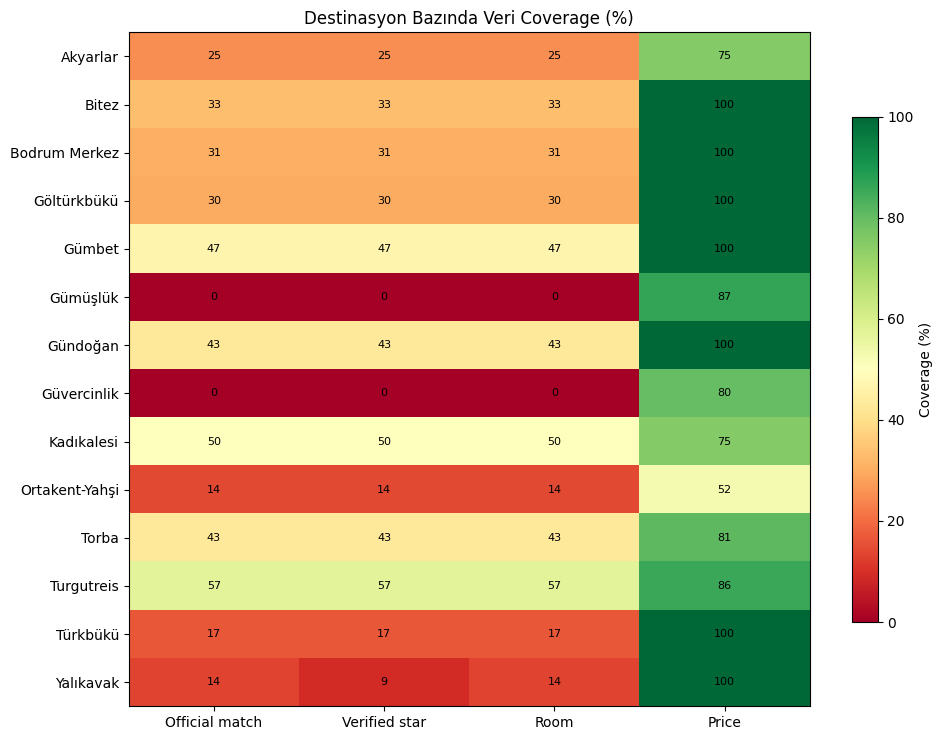

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/destination_intelligence/coverage_by_area.png')

In [7]:
coverage_columns = [
    "area", "sample_hotel_count", "official_attribute_n", "verified_star_n", "room_capacity_n",
    "price_observation_n", "official_match_rate_pct", "verified_star_coverage_pct",
    "room_coverage_pct", "price_coverage_pct", "coverage_flag", "low_sample_flag", "score_confidence",
]
coverage_table = master[coverage_columns]
display(coverage_table)

coverage_matrix = master.set_index("area")[[
    "official_match_rate_pct", "verified_star_coverage_pct", "room_coverage_pct", "price_coverage_pct"
]]
fig, ax = plt.subplots(figsize=(10, 7.5))
image = ax.imshow(coverage_matrix.to_numpy(), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(4), ["Official match", "Verified star", "Room", "Price"])
ax.set_yticks(range(14), coverage_matrix.index)
ax.set_title("Destinasyon Bazında Veri Coverage (%)")
for i in range(coverage_matrix.shape[0]):
    for j in range(coverage_matrix.shape[1]):
        value = coverage_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, shrink=0.75, label="Coverage (%)")
save_fig(fig, "coverage_by_area.png")


In [8]:
low_coverage_areas = master.loc[master["low_coverage_flag"], "area"].tolist()
display(Markdown(
    f"**Bulgu:** {len(low_coverage_areas)}/14 alan düşük resmî coverage bayrağı taşıyor: "
    + ", ".join(low_coverage_areas)
    + ". Gümüşlük ve Güvercinlik'te yüksek güvenli eşleşme yoktur; kapasite bilinmiyor olarak korunur."
))


**Bulgu:** 10/14 alan düşük resmî coverage bayrağı taşıyor: Akyarlar, Bitez, Bodrum Merkez, Göltürkbükü, Gümüşlük, Güvercinlik, Kadıkalesi, Ortakent-Yahşi, Türkbükü, Yalıkavak. Gümüşlük ve Güvercinlik'te yüksek güvenli eşleşme yoktur; kapasite bilinmiyor olarak korunur.

### 5. Supply ve resmî eşleşme kapasitesi

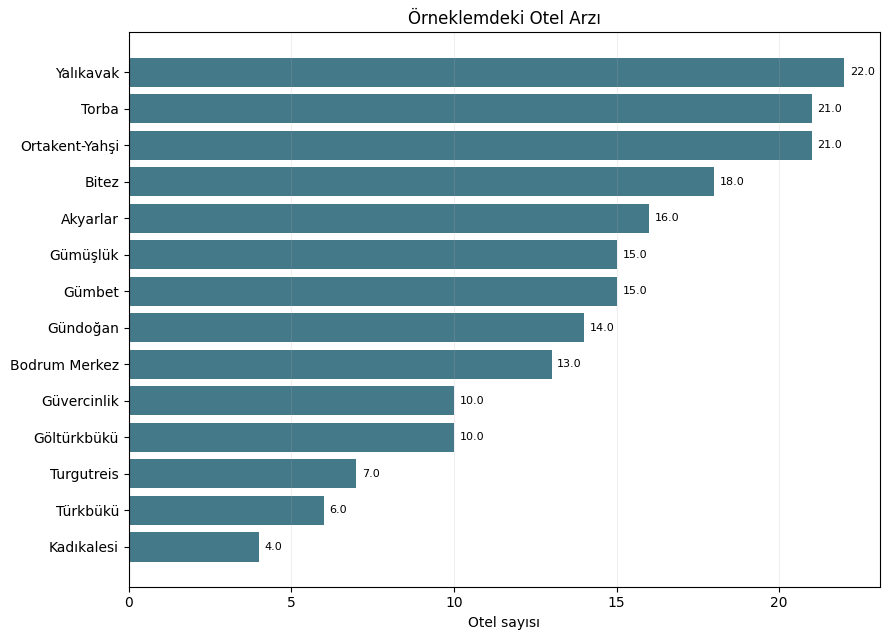

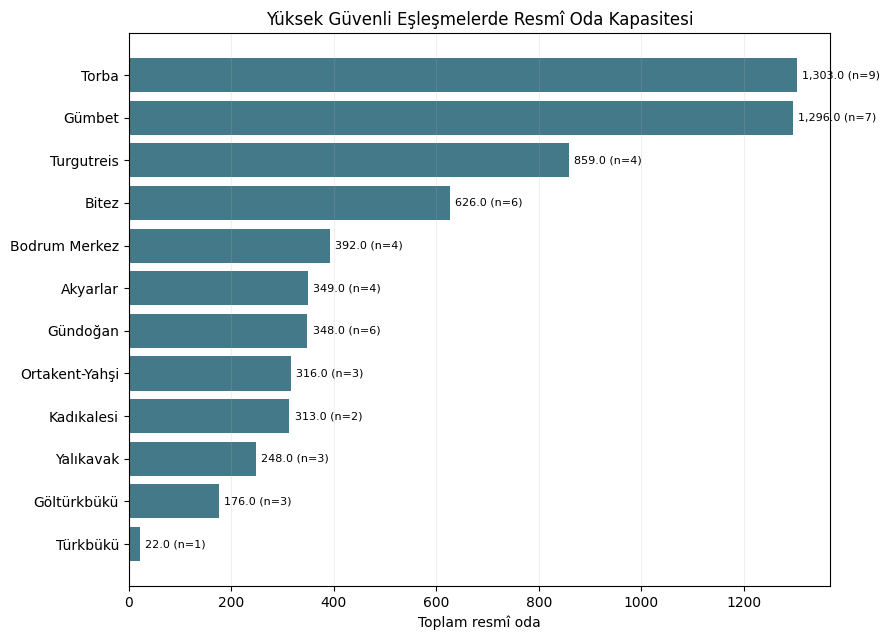

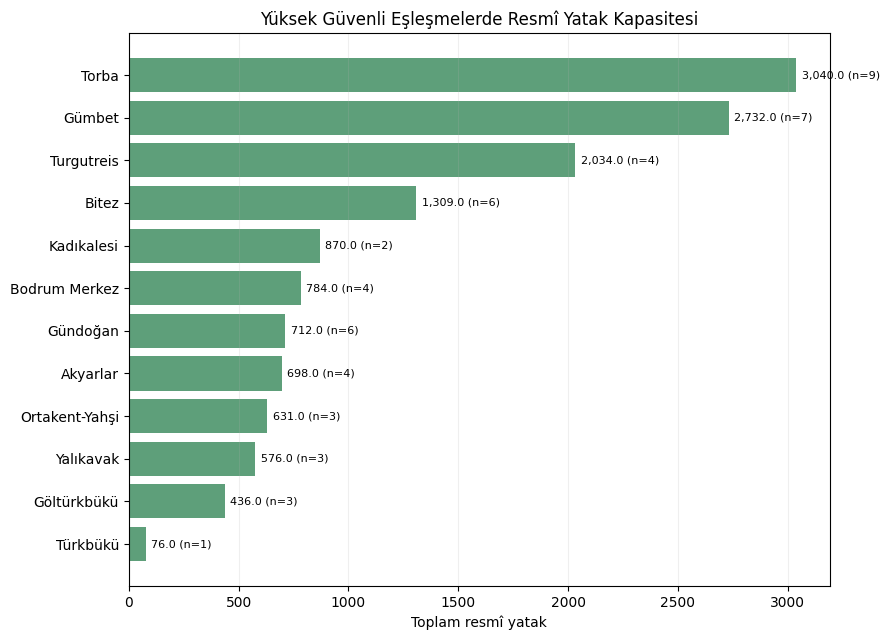

In [9]:
horizontal_bar(master, "sample_hotel_count", "Örneklemdeki Otel Arzı", "Otel sayısı",
               "sample_hotel_count_by_area.png", note_col=None)
horizontal_bar(master, "total_official_rooms", "Yüksek Güvenli Eşleşmelerde Resmî Oda Kapasitesi",
               "Toplam resmî oda", "official_room_capacity_by_area.png", color=PRIMARY, note_col="room_capacity_n")
horizontal_bar(master, "total_official_beds", "Yüksek Güvenli Eşleşmelerde Resmî Yatak Kapasitesi",
               "Toplam resmî yatak", "official_bed_capacity_by_area.png", color=SECONDARY, note_col="bed_capacity_n")


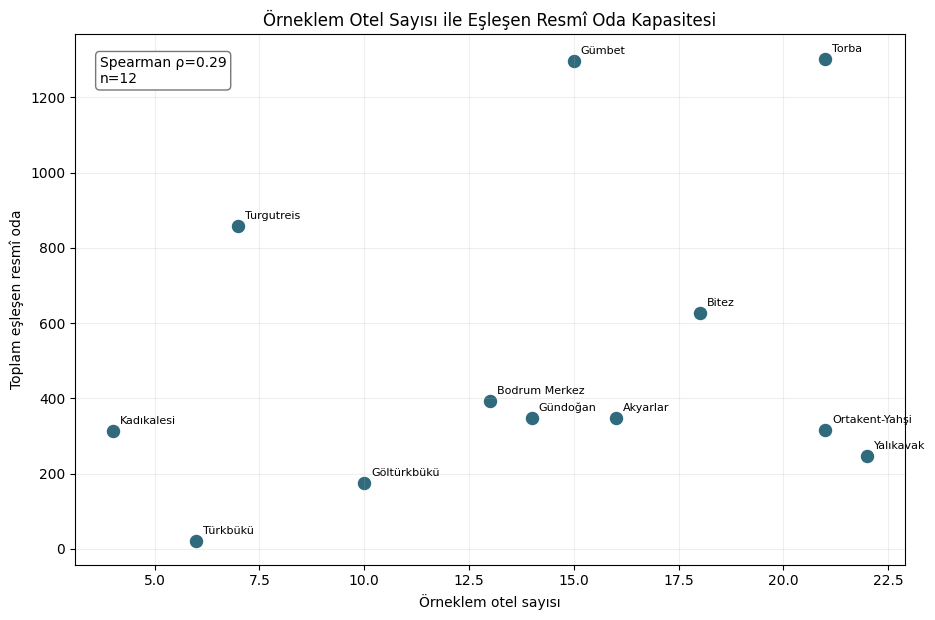

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/destination_intelligence/sample_supply_vs_official_capacity.png')

In [10]:
capacity_complete = master.dropna(subset=["total_official_rooms"])
supply_capacity_rho = capacity_complete["sample_hotel_count"].corr(
    capacity_complete["total_official_rooms"], method="spearman"
)
fig, ax = plt.subplots(figsize=(9.5, 6.3))
ax.scatter(capacity_complete["sample_hotel_count"], capacity_complete["total_official_rooms"], s=75, color=PRIMARY)
for row in capacity_complete.itertuples():
    ax.annotate(row.area, (row.sample_hotel_count, row.total_official_rooms), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(title="Örneklem Otel Sayısı ile Eşleşen Resmî Oda Kapasitesi", xlabel="Örneklem otel sayısı", ylabel="Toplam eşleşen resmî oda")
ax.text(0.03, 0.96, f"Spearman ρ={supply_capacity_rho:.2f}\nn={len(capacity_complete)}", transform=ax.transAxes,
        va="top", bbox=dict(boxstyle="round", facecolor="white", edgecolor=NEUTRAL))
ax.grid(alpha=0.2)
save_fig(fig, "sample_supply_vs_official_capacity.png")


### 6. Capacity yapısı

,area,total_official_rooms,total_official_beds,median_official_room_count,median_official_bed_count,beds_per_room_destination,room_capacity_n
0,Akyarlar,349.000,698.000,70.000,140.000,2.000,4
1,Bitez,626.000,"1,309.000",87.500,179.500,2.091,6
2,Bodrum Merkez,392.000,784.000,84.500,169.000,2.000,4
3,Göltürkbükü,176.000,436.000,36.000,72.000,2.477,3
4,Gümbet,"1,296.000","2,732.000",149.000,298.000,2.108,7
5,Gümüşlük,NaN,NaN,NaN,NaN,NaN,0
6,Gündoğan,348.000,712.000,42.000,88.000,2.046,6
7,Güvercinlik,NaN,NaN,NaN,NaN,NaN,0
8,Kadıkalesi,313.000,870.000,156.500,435.000,2.780,2
9,Ortakent-Yahşi,316.000,631.000,44.000,95.000,1.997,3


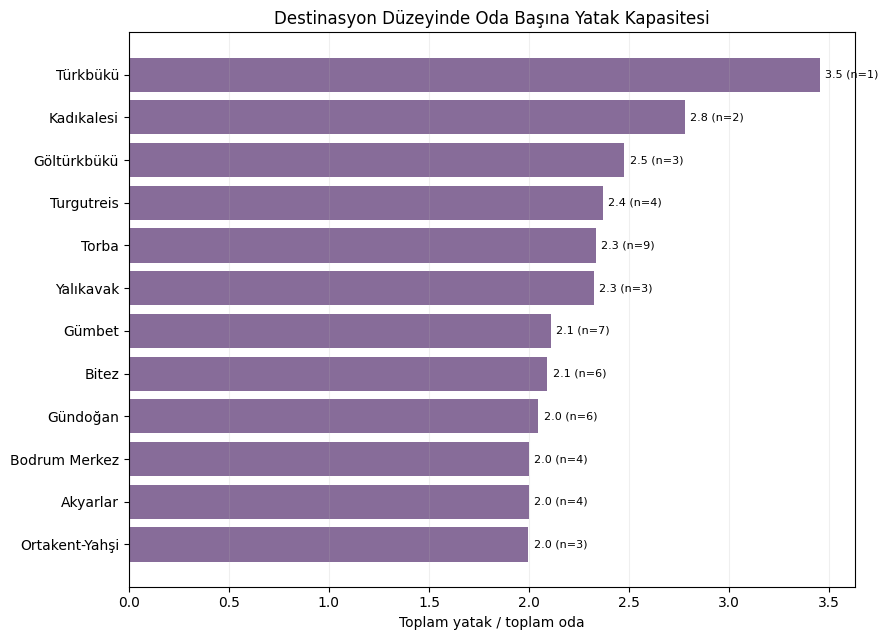

In [11]:
capacity_columns = [
    "area", "total_official_rooms", "total_official_beds", "median_official_room_count",
    "median_official_bed_count", "beds_per_room_destination", "room_capacity_n",
]
display(master[capacity_columns])
horizontal_bar(master, "beds_per_room_destination", "Destinasyon Düzeyinde Oda Başına Yatak Kapasitesi",
               "Toplam yatak / toplam oda", "beds_per_room_by_area.png", color=PURPLE, note_col="room_capacity_n")


In [12]:
display(Markdown(
    "**Yorum:** `beds_per_room_destination`, yalnız eşleşen tesislerin toplam yatak/toplam oda "
    "oranıdır. Oda tipi, gerçek doluluk veya kişi kapasitesi dağılımını doğrudan göstermez."
))


**Yorum:** `beds_per_room_destination`, yalnız eşleşen tesislerin toplam yatak/toplam oda oranıdır. Oda tipi, gerçek doluluk veya kişi kapasitesi dağılımını doğrudan göstermez.

### 7. Customer Satisfaction

,area,avg_google_rating,median_google_rating,avg_weighted_google_rating,avg_rating_gap_from_area_median,sample_hotel_count
6,Gündoğan,4.586,4.500,4.417,0.086,14
3,Göltürkbükü,4.480,4.450,4.416,0.030,10
10,Torba,4.367,4.400,4.400,-0.033,21
0,Akyarlar,4.450,4.400,4.395,0.050,16
5,Gümüşlük,4.507,4.500,4.392,0.007,15
13,Yalıkavak,4.464,4.450,4.391,0.014,22
11,Turgutreis,4.429,4.600,4.391,-0.171,7
12,Türkbükü,4.450,4.450,4.387,-0.000,6
9,Ortakent-Yahşi,4.295,4.300,4.334,-0.005,21
8,Kadıkalesi,4.300,4.350,4.309,-0.050,4


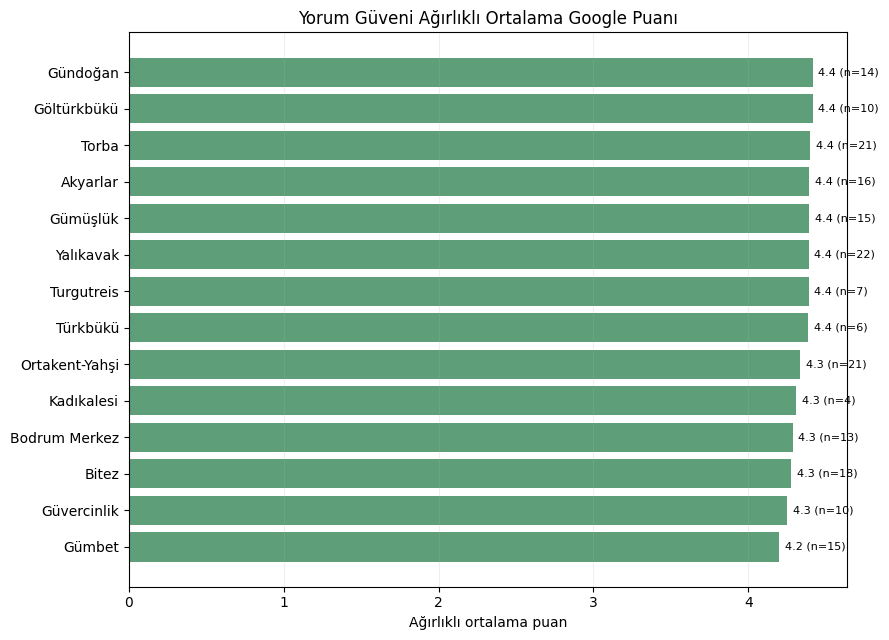

,raw_rank,weighted_rank,rank_change
area,,,
Torba,8.000,3.000,-5.000
Gümüşlük,2.000,5.000,3.000
Türkbükü,5.000,8.000,3.000
Bodrum Merkez,9.000,11.000,2.000
Ortakent-Yahşi,11.000,9.000,-2.000
Yalıkavak,4.000,6.000,2.000
Akyarlar,5.000,4.000,-1.000
Göltürkbükü,3.000,2.000,-1.000
Kadıkalesi,9.000,10.000,1.000


In [13]:
satisfaction = master[[
    "area", "avg_google_rating", "median_google_rating", "avg_weighted_google_rating",
    "avg_rating_gap_from_area_median", "sample_hotel_count",
]].sort_values("avg_weighted_google_rating", ascending=False)
display(satisfaction)
horizontal_bar(master, "avg_weighted_google_rating", "Yorum Güveni Ağırlıklı Ortalama Google Puanı",
               "Ağırlıklı ortalama puan", "weighted_rating_by_area.png", color=SECONDARY,
               note_col="sample_hotel_count")

raw_rank = master.set_index("area")["avg_google_rating"].rank(ascending=False, method="min")
weighted_rank = master.set_index("area")["avg_weighted_google_rating"].rank(ascending=False, method="min")
rating_rank_change = pd.DataFrame({"raw_rank": raw_rank, "weighted_rank": weighted_rank})
rating_rank_change["rank_change"] = rating_rank_change["weighted_rank"] - rating_rank_change["raw_rank"]
display(rating_rank_change.sort_values("rank_change", key=abs, ascending=False))


### 8. Popularity: toplam görünürlük ve otel başına yoğunluk

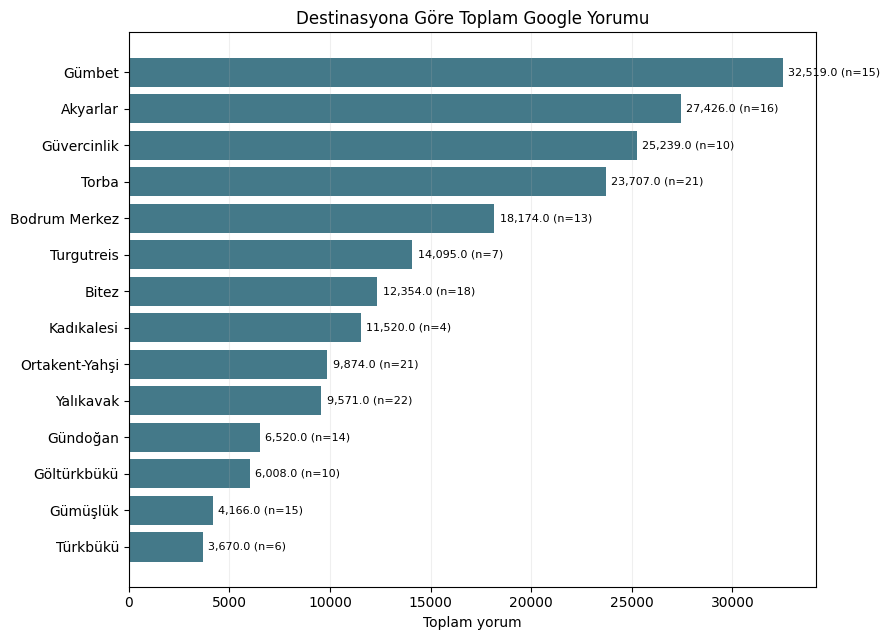

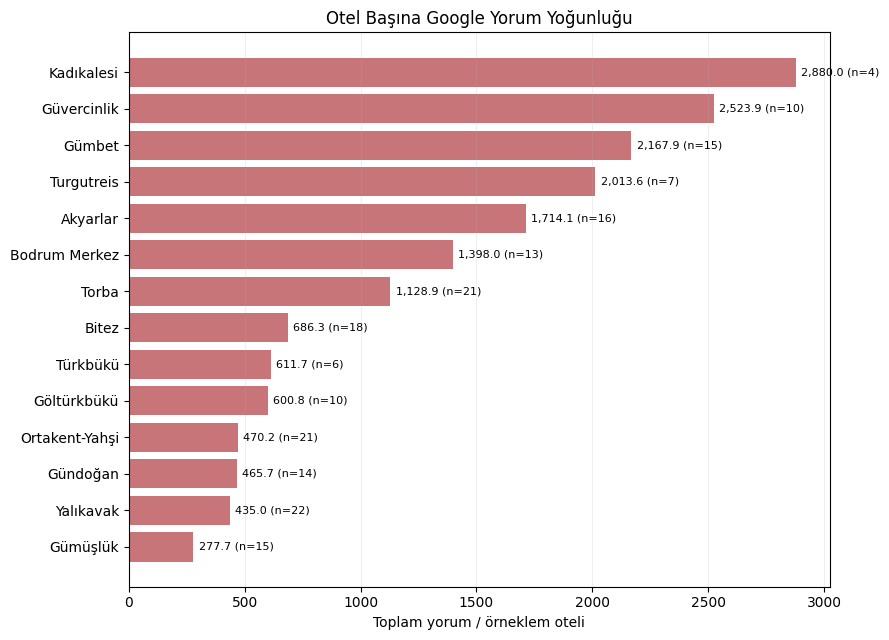

In [14]:
horizontal_bar(master, "total_google_reviews", "Destinasyona Göre Toplam Google Yorumu",
               "Toplam yorum", "total_reviews_by_area.png", color=PRIMARY, note_col="sample_hotel_count")
horizontal_bar(master, "reviews_per_sample_hotel", "Otel Başına Google Yorum Yoğunluğu",
               "Toplam yorum / örneklem oteli", "review_intensity_by_area.png", color=ACCENT,
               note_col="sample_hotel_count")


### 9. Price Position

Fiyat yalnız 2026-08-24 arama snapshot'ıdır. `price_index=100`, 14 alan medyan fiyatlarının
medyanına eşittir; yıllık veya gerçek piyasa fiyat seviyesi değildir.


,area,price_observation_n,price_coverage_pct,median_price_snapshot,mean_price_snapshot,overall_area_median_price,price_index
12,Türkbükü,6,100.000,532.000,956.000,167.000,318.563
8,Kadıkalesi,3,75.000,446.000,583.667,167.000,267.066
13,Yalıkavak,22,100.000,329.500,355.045,167.000,197.305
10,Torba,17,81.000,248.000,532.647,167.000,148.503
0,Akyarlar,12,75.000,192.500,284.417,167.000,115.269
6,Gündoğan,14,100.000,189.500,211.214,167.000,113.473
2,Bodrum Merkez,13,100.000,169.000,242.846,167.000,101.198
3,Göltürkbükü,10,100.000,165.000,311.900,167.000,98.802
7,Güvercinlik,8,80.000,162.500,195.625,167.000,97.305
1,Bitez,18,100.000,131.500,208.611,167.000,78.743


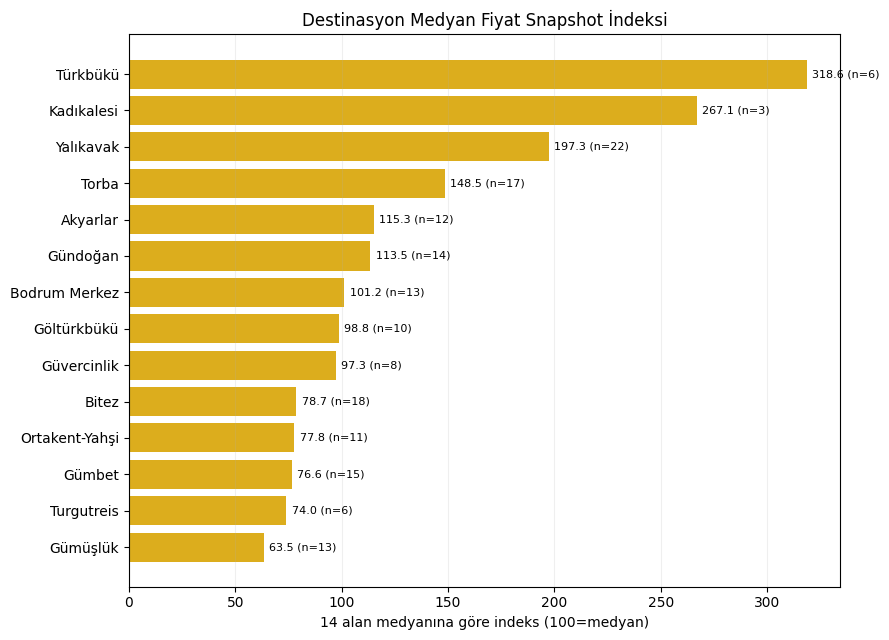

In [15]:
price_table = master[[
    "area", "price_observation_n", "price_coverage_pct", "median_price_snapshot",
    "mean_price_snapshot", "overall_area_median_price", "price_index",
]].sort_values("price_index", ascending=False)
display(price_table)
horizontal_bar(master, "price_index", "Destinasyon Medyan Fiyat Snapshot İndeksi",
               "14 alan medyanına göre indeks (100=medyan)", "median_price_index_by_area.png",
               color=HIGHLIGHT, note_col="price_observation_n")


### 10. Luxury supply bileşenleri

,area,verified_star_n,verified_five_star_count,verified_five_star_share,official_boutique_count,median_official_room_count,price_index,official_match_rate_pct,low_coverage_flag,luxury_index,luxury_rank_eligible,luxury_rank
10,Torba,9,5,0.556,2,76.000,148.503,42.900,False,62.222,True,2.000
11,Turgutreis,4,4,1.000,1,220.500,73.952,57.100,False,65.232,True,1.000
1,Bitez,6,3,0.500,0,87.500,78.743,33.300,True,39.796,False,NaN
2,Bodrum Merkez,4,2,0.500,0,84.500,101.198,30.800,True,36.437,False,NaN
4,Gümbet,7,2,0.286,0,149.000,76.647,46.700,False,24.978,True,3.000
13,Yalıkavak,2,2,1.000,1,108.000,197.305,13.600,True,67.739,False,NaN
3,Göltürkbükü,3,1,0.333,0,36.000,98.802,30.000,True,23.488,False,NaN
6,Gündoğan,6,1,0.167,1,42.000,113.473,42.900,False,18.547,True,4.000
8,Kadıkalesi,2,1,0.500,0,156.500,267.066,50.000,True,49.944,False,NaN
0,Akyarlar,4,0,0.000,1,70.000,115.269,25.000,True,6.092,False,NaN


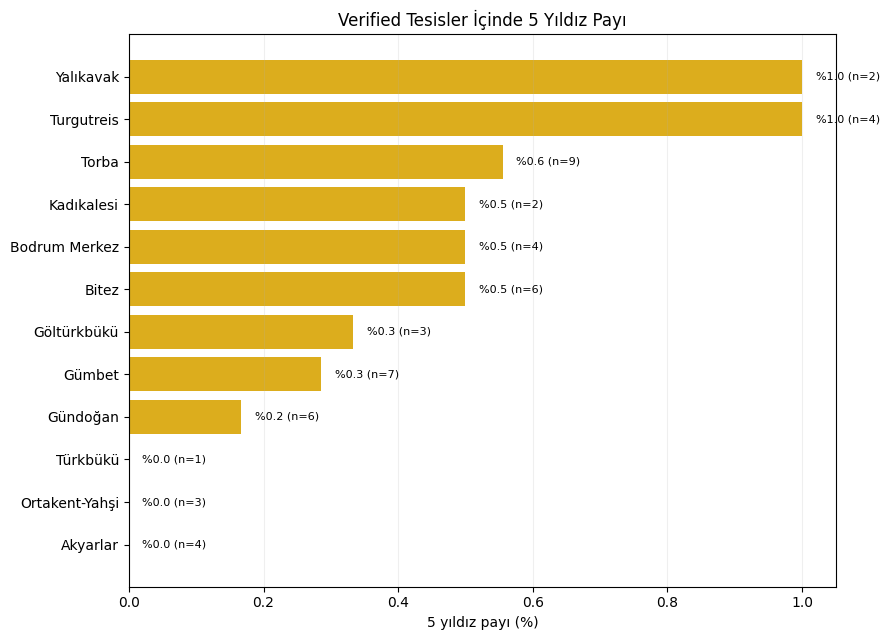

In [16]:
luxury_components = master[[
    "area", "verified_star_n", "verified_five_star_count", "verified_five_star_share",
    "official_boutique_count", "median_official_room_count", "price_index",
    "official_match_rate_pct", "low_coverage_flag", "luxury_index", "luxury_rank_eligible", "luxury_rank",
]]
display(luxury_components.sort_values("verified_five_star_count", ascending=False))
horizontal_bar(master, "verified_five_star_share", "Verified Tesisler İçinde 5 Yıldız Payı",
               "5 yıldız payı (%)", "five_star_share_by_area.png", color=HIGHLIGHT,
               note_col="verified_star_n", percent=True)


Pay grafiği `verified_star_n` ile birlikte okunmalıdır. Düşük coverage alanları lüks sırasına
alınmaz; 0 doğrulanmış yıldız, “lüks arz yok” değil, “bu eşleşme katmanında bilinmiyor” anlamına gelir.


### 11. Value potential: fiyat × ağırlıklı memnuniyet

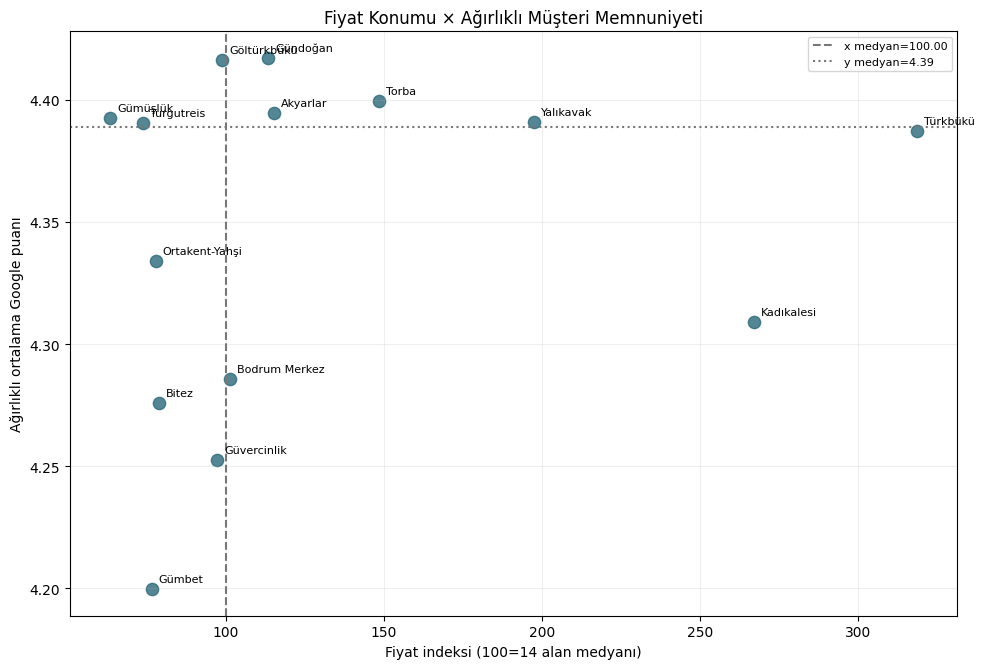

,area,price_index,avg_weighted_google_rating,value_index,value_quadrant
5,Gümüşlük,63.473,4.392,94.330,High satisfaction + lower price
3,Göltürkbükü,98.802,4.416,92.882,High satisfaction + lower price
11,Turgutreis,73.952,4.391,91.843,High satisfaction + lower price
6,Gündoğan,113.473,4.417,90.200,High satisfaction + higher price
0,Akyarlar,115.269,4.395,84.654,High satisfaction + higher price
10,Torba,148.503,4.400,79.321,High satisfaction + higher price
9,Ortakent-Yahşi,77.844,4.334,78.105,Lower satisfaction + lower price
13,Yalıkavak,197.305,4.391,67.702,High satisfaction + higher price
1,Bitez,78.743,4.276,64.526,Lower satisfaction + lower price
2,Bodrum Merkez,101.198,4.286,62.395,Lower satisfaction + higher price


In [17]:
value_x_median, value_y_median = quadrant_plot(
    master, "price_index", "avg_weighted_google_rating", "value_quadrant",
    "Fiyat Konumu × Ağırlıklı Müşteri Memnuniyeti",
    "Fiyat indeksi (100=14 alan medyanı)", "Ağırlıklı ortalama Google puanı",
    "price_satisfaction_value_quadrant.png",
)
display(master[["area", "price_index", "avg_weighted_google_rating", "value_index", "value_quadrant"]].sort_values("value_index", ascending=False))


### 12. Popularity × Satisfaction quadrant

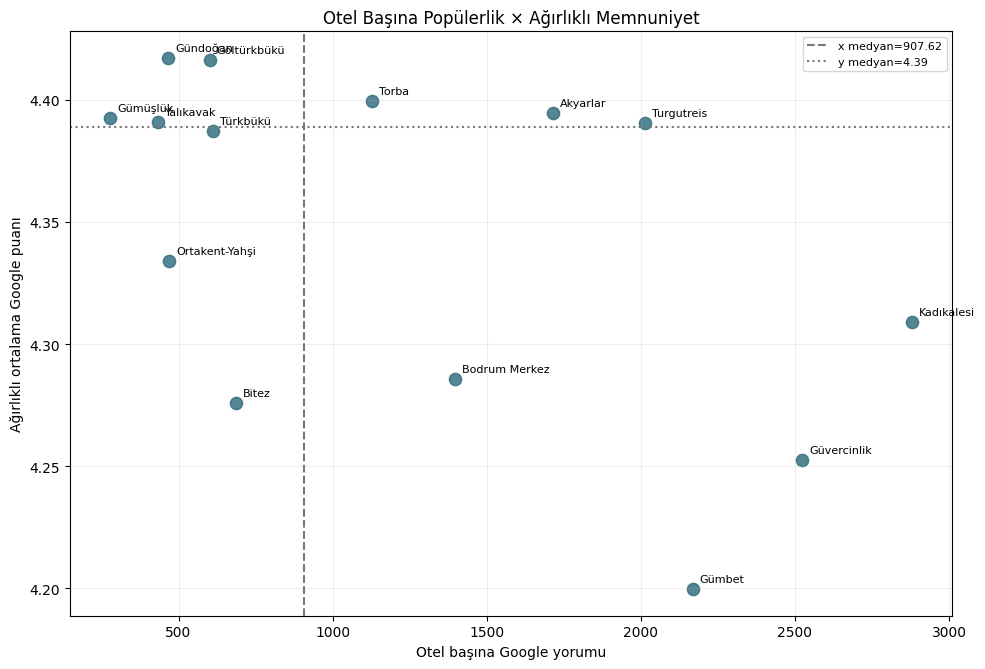

,area,sample_hotel_count,reviews_per_sample_hotel,avg_weighted_google_rating,popularity_satisfaction_quadrant,score_confidence
10,Torba,21,"1,128.905",4.400,High popularity + high satisfaction,high
0,Akyarlar,16,"1,714.125",4.395,High popularity + high satisfaction,medium
11,Turgutreis,7,"2,013.571",4.391,High popularity + high satisfaction,medium
2,Bodrum Merkez,13,"1,398.000",4.286,High popularity + lower satisfaction,medium
4,Gümbet,15,"2,167.933",4.200,High popularity + lower satisfaction,high
7,Güvercinlik,10,"2,523.900",4.253,High popularity + lower satisfaction,low
8,Kadıkalesi,4,"2,880.000",4.309,High popularity + lower satisfaction,low
5,Gümüşlük,15,277.733,4.392,Lower popularity + high satisfaction,low
13,Yalıkavak,22,435.045,4.391,Lower popularity + high satisfaction,medium
6,Gündoğan,14,465.714,4.417,Lower popularity + high satisfaction,high


In [18]:
pop_x_median, pop_y_median = quadrant_plot(
    master, "reviews_per_sample_hotel", "avg_weighted_google_rating", "popularity_satisfaction_quadrant",
    "Otel Başına Popülerlik × Ağırlıklı Memnuniyet",
    "Otel başına Google yorumu", "Ağırlıklı ortalama Google puanı",
    "popularity_satisfaction_quadrant.png",
)
popularity_quadrants = master[[
    "area", "sample_hotel_count", "reviews_per_sample_hotel", "avg_weighted_google_rating",
    "popularity_satisfaction_quadrant", "score_confidence",
]]
display(popularity_quadrants.sort_values(["popularity_satisfaction_quadrant", "reviews_per_sample_hotel"]))


### 13. Price × Luxury quadrant (coverage uygun alanlar)

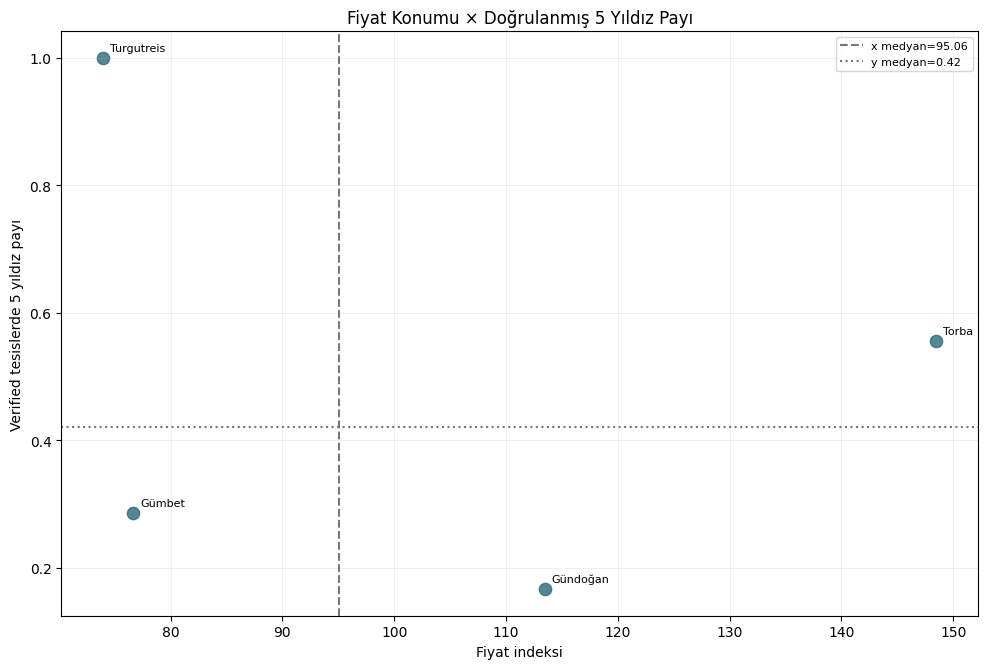

,area,price_index,verified_star_n,verified_five_star_share,official_match_rate_pct,price_luxury_quadrant_eligible,price_luxury_quadrant
0,Akyarlar,115.269,4,0.000,25.000,False,<NA>
1,Bitez,78.743,6,0.500,33.300,False,<NA>
2,Bodrum Merkez,101.198,4,0.500,30.800,False,<NA>
3,Göltürkbükü,98.802,3,0.333,30.000,False,<NA>
4,Gümbet,76.647,7,0.286,46.700,True,Lower price + lower five-star share
5,Gümüşlük,63.473,0,NaN,0.000,False,<NA>
6,Gündoğan,113.473,6,0.167,42.900,True,Higher price + lower five-star share
7,Güvercinlik,97.305,0,NaN,0.000,False,<NA>
8,Kadıkalesi,267.066,2,0.500,50.000,False,<NA>
9,Ortakent-Yahşi,77.844,3,0.000,14.300,False,<NA>


In [19]:
eligible_luxury = master["price_luxury_quadrant_eligible"]
luxury_x_median, luxury_y_median = quadrant_plot(
    master, "price_index", "verified_five_star_share", "price_luxury_quadrant",
    "Fiyat Konumu × Doğrulanmış 5 Yıldız Payı",
    "Fiyat indeksi", "Verified tesislerde 5 yıldız payı",
    "price_luxury_quadrant.png", eligible=eligible_luxury,
)
price_luxury_quadrants = master[[
    "area", "price_index", "verified_star_n", "verified_five_star_share",
    "official_match_rate_pct", "price_luxury_quadrant_eligible", "price_luxury_quadrant",
]]
display(price_luxury_quadrants)


### 14. Ayrı destinasyon alt indeksleri ve score confidence

,area,quality_index,popularity_index,luxury_index,value_index,supply_capacity_index,score_confidence,low_coverage_flag,luxury_rank_eligible,luxury_rank
0,Akyarlar,89.613,68.772,6.092,84.654,37.726,medium,True,False,NaN
1,Bitez,35.038,22.902,39.796,64.526,55.509,medium,True,False,NaN
2,Bodrum Merkez,39.580,46.663,36.437,62.395,34.257,medium,True,False,NaN
3,Göltürkbükü,99.614,10.260,23.488,92.882,19.167,medium,True,False,NaN
4,Gümbet,0.000,86.318,24.978,47.418,83.391,high,False,True,3.000
5,Gümüşlük,88.660,0.860,NaN,94.330,NaN,low,True,False,NaN
6,Gündoğan,100.000,8.551,18.547,90.200,34.154,high,False,True,4.000
7,Güvercinlik,24.335,80.540,NaN,55.536,NaN,low,True,False,NaN
8,Kadıkalesi,50.369,63.605,49.944,35.279,16.502,low,True,False,NaN
9,Ortakent-Yahşi,61.843,14.450,1.690,78.105,45.373,low,True,False,NaN


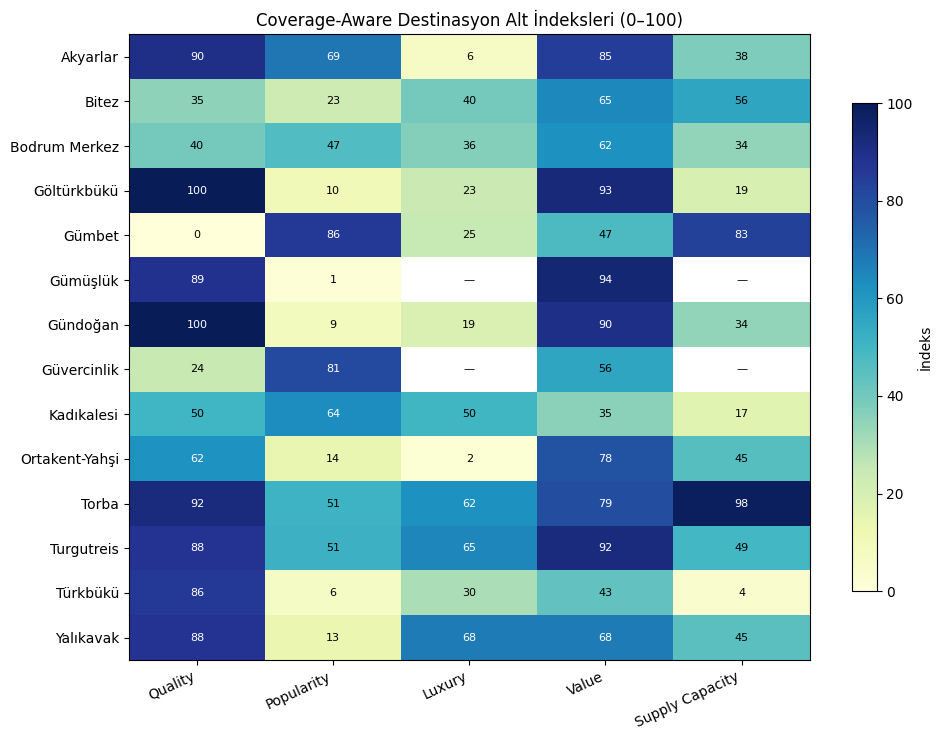

In [20]:
subindex_columns = ["quality_index", "popularity_index", "luxury_index", "value_index", "supply_capacity_index"]
subindices = master[[
    "area", *subindex_columns, "score_confidence", "low_coverage_flag",
    "luxury_rank_eligible", "luxury_rank",
]]
display(subindices)
index_heatmap(master, subindex_columns, "destination_subindices_heatmap.png")


In [21]:
component_inventory = pd.DataFrame([
    ("quality_index", "avg_weighted_google_rating", "single component", "No official-data dependency"),
    ("popularity_index", "reviews_per_sample_hotel; total_google_reviews", "50/50", "Both hotel-sample components required"),
    ("luxury_index", "verified_five_star_share; verified_five_star_count; price_index", "40/30/30", "Minimum 2 components; rank only if coverage adequate"),
    ("value_index", "weighted rating; inverse price index", "50/50", "No missing component imputation"),
    ("supply_capacity_index", "sample_hotel_count; official rooms; official beds", "1/3 each", "Minimum 2 components; zero-match capacity remains NaN"),
], columns=["index", "components", "weights", "coverage_rule"])
display(component_inventory)


,index,components,weights,coverage_rule
0,quality_index,avg_weighted_google_rating,single component,No official-data dependency
1,popularity_index,reviews_per_sample_hotel; total_google_reviews,50/50,Both hotel-sample components required
2,luxury_index,verified_five_star_share; verified_five_star_count; price_index,40/30/30,Minimum 2 components; rank only if coverage adequate
3,value_index,weighted rating; inverse price index,50/50,No missing component imputation
4,supply_capacity_index,sample_hotel_count; official rooms; official beds,1/3 each,Minimum 2 components; zero-match capacity remains NaN


### 15. Value index weight sensitivity

,area,scenario,rating_weight,inverse_price_weight,value_index,rank,rank_spread,ranking_sensitive
0,Akyarlar,balanced,0.500,0.500,84.654,5.000,1.000,False
28,Akyarlar,price_heavy,0.300,0.700,82.670,6.000,1.000,False
14,Akyarlar,rating_heavy,0.700,0.300,86.638,5.000,1.000,False
1,Bitez,balanced,0.500,0.500,64.526,9.000,4.000,True
29,Bitez,price_heavy,0.300,0.700,76.321,7.000,4.000,True
15,Bitez,rating_heavy,0.700,0.300,52.730,11.000,4.000,True
2,Bodrum Merkez,balanced,0.500,0.500,62.395,10.000,1.000,False
30,Bodrum Merkez,price_heavy,0.300,0.700,71.522,9.000,1.000,False
16,Bodrum Merkez,rating_heavy,0.700,0.300,53.269,10.000,1.000,False
3,Göltürkbükü,balanced,0.500,0.500,92.882,2.000,2.000,False


,area,min_rank,max_rank,rank_spread,ranking_sensitive
12,Türkbükü,9.000,14.000,5.000,True
13,Yalıkavak,7.000,12.000,5.000,True
1,Bitez,7.000,11.000,4.000,True
4,Gümbet,11.000,14.000,3.000,False
9,Ortakent-Yahşi,5.000,8.000,3.000,False
3,Göltürkbükü,1.000,3.000,2.000,False
5,Gümüşlük,1.000,3.000,2.000,False
6,Gündoğan,2.000,4.000,2.000,False
7,Güvercinlik,10.000,12.000,2.000,False
10,Torba,6.000,8.000,2.000,False


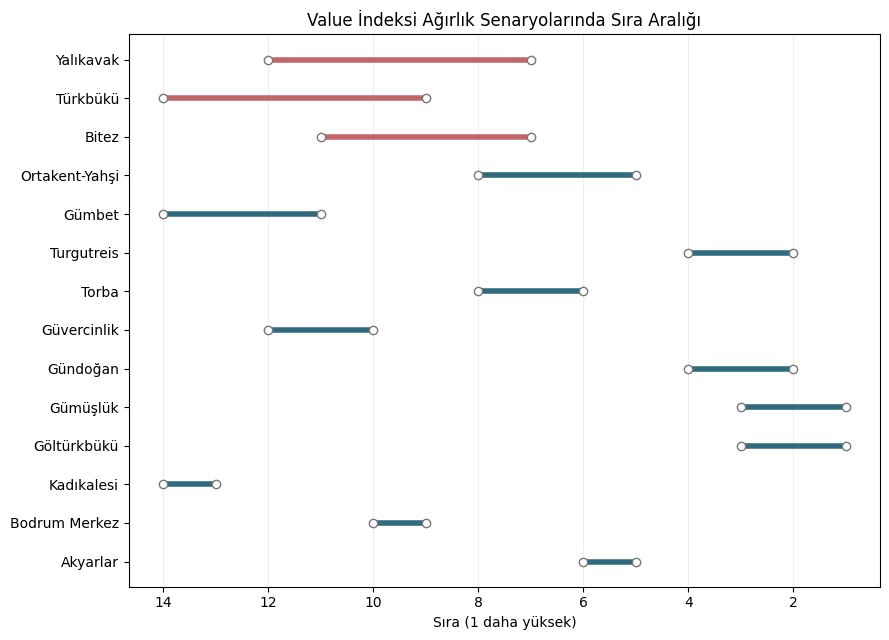

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/destination_intelligence/value_index_rank_sensitivity.png')

In [22]:
sensitivity = value_sensitivity(master)
display(sensitivity.sort_values(["area", "scenario"]))

rank_ranges = sensitivity.groupby("area").agg(
    min_rank=("rank", "min"), max_rank=("rank", "max"),
    rank_spread=("rank_spread", "first"), ranking_sensitive=("ranking_sensitive", "first"),
).reset_index().sort_values("rank_spread", ascending=False)
display(rank_ranges)

fig, ax = plt.subplots(figsize=(9, 6.5))
plot_ranges = rank_ranges.sort_values("rank_spread")
for y, row in enumerate(plot_ranges.itertuples()):
    ax.plot([row.min_rank, row.max_rank], [y, y], color=ACCENT if row.ranking_sensitive else PRIMARY, linewidth=4)
    ax.scatter([row.min_rank, row.max_rank], [y, y], color="white", edgecolor=NEUTRAL, zorder=3)
ax.set_yticks(range(len(plot_ranges)), plot_ranges["area"])
ax.invert_xaxis()
ax.set(title="Value İndeksi Ağırlık Senaryolarında Sıra Aralığı", xlabel="Sıra (1 daha yüksek)")
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "value_index_rank_sensitivity.png")


### 16. Açıklanabilir destination archetypes

In [23]:
archetypes = master[[
    "area", "archetype", "quality_index", "popularity_index", "luxury_index",
    "value_index", "supply_capacity_index", "score_confidence", "coverage_flag",
]]
display(archetypes.sort_values(["archetype", "area"]))


,area,archetype,quality_index,popularity_index,luxury_index,value_index,supply_capacity_index,score_confidence,coverage_flag
2,Bodrum Merkez,Balanced,39.580,46.663,36.437,62.395,34.257,medium,LOW
9,Ortakent-Yahşi,Balanced,61.843,14.450,1.690,78.105,45.373,low,LOW
12,Türkbükü,Balanced,86.188,6.416,30.000,43.094,3.704,low,LOW
1,Bitez,Capacity-Heavy Resort Area,35.038,22.902,39.796,64.526,55.509,medium,LOW
4,Gümbet,Capacity-Heavy Resort Area,0.000,86.318,24.978,47.418,83.391,high,ADEQUATE_FOR_EXPLORATORY
10,Torba,Capacity-Heavy Resort Area,91.976,51.082,62.222,79.321,98.148,high,ADEQUATE_FOR_EXPLORATORY
0,Akyarlar,High Popularity,89.613,68.772,6.092,84.654,37.726,medium,LOW
7,Güvercinlik,High Popularity,24.335,80.540,NaN,55.536,NaN,low,LOW
8,Kadıkalesi,High Popularity,50.369,63.605,49.944,35.279,16.502,low,LOW
13,Yalıkavak,High Satisfaction / Low Visibility,87.869,13.250,67.739,67.702,44.837,medium,LOW


### 17. Marina / haftalık pazar bağlamı

,has_marina_official_context,destination_n,median_price_index,median_weighted_rating,median_review_intensity
0,False,11,98.802,4.387,686.333
1,True,3,101.198,4.391,"1,398.000"


,has_weekly_market_official_context,destination_n,median_price_index,median_weighted_rating,median_review_intensity
0,False,2,207.784,4.354,"2,004.452"
1,True,12,98.054,4.389,649.000


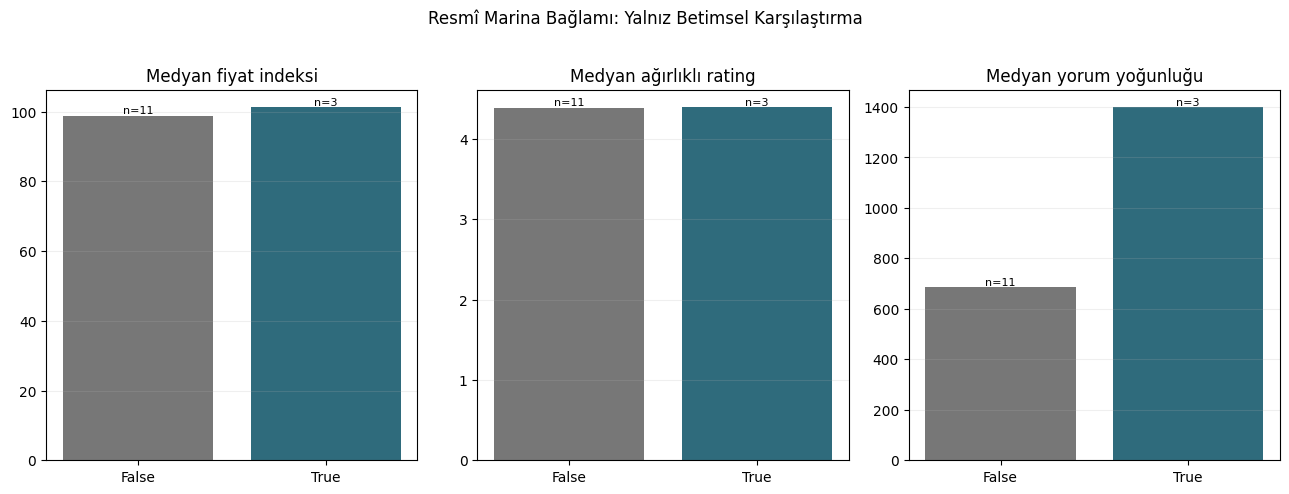

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/destination_intelligence/marina_context_descriptive_comparison.png')

In [24]:
context_comparison = (
    master.groupby("has_marina_official_context", dropna=False)
    .agg(
        destination_n=("area", "size"),
        median_price_index=("price_index", "median"),
        median_weighted_rating=("avg_weighted_google_rating", "median"),
        median_review_intensity=("reviews_per_sample_hotel", "median"),
    ).reset_index()
)
market_comparison = (
    master.groupby("has_weekly_market_official_context", dropna=False)
    .agg(
        destination_n=("area", "size"),
        median_price_index=("price_index", "median"),
        median_weighted_rating=("avg_weighted_google_rating", "median"),
        median_review_intensity=("reviews_per_sample_hotel", "median"),
    ).reset_index()
)
display(context_comparison)
display(market_comparison)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
metrics = ["median_price_index", "median_weighted_rating", "median_review_intensity"]
titles = ["Medyan fiyat indeksi", "Medyan ağırlıklı rating", "Medyan yorum yoğunluğu"]
for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(context_comparison["has_marina_official_context"].astype(str), context_comparison[metric], color=[NEUTRAL, PRIMARY])
    ax.set_title(title); ax.grid(axis="y", alpha=0.2)
    for x, row in enumerate(context_comparison.itertuples()):
        ax.text(x, getattr(row, metric), f"n={row.destination_n}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Resmî Marina Bağlamı: Yalnız Betimsel Karşılaştırma", y=1.02)
save_fig(fig, "marina_context_descriptive_comparison.png")


In [25]:
display(Markdown(
    "**Sınırlılık:** Marina/pazar grupları küçüktür; test yapılmamıştır. Bu bağlamlar fiyat, rating "
    "veya görünürlüğün nedeni olarak yorumlanamaz."
))


**Sınırlılık:** Marina/pazar grupları küçüktür; test yapılmamıştır. Bu bağlamlar fiyat, rating veya görünürlüğün nedeni olarak yorumlanamaz.

### 18. Keşifsel Spearman korelasyonları

In [26]:
correlation_pairs = [
    ("price_index", "avg_weighted_google_rating"),
    ("price_index", "verified_five_star_share"),
    ("total_official_rooms", "reviews_per_sample_hotel"),
    ("total_official_rooms", "avg_weighted_google_rating"),
    ("verified_five_star_share", "price_index"),
]
correlations = spearman_correlations(master, correlation_pairs)
display(correlations)


,metric_x,metric_y,n,spearman_rho,p_value,interpretation_note
0,price_index,avg_weighted_google_rating,14,0.240,0.409,Exploratory; small destination n and coverage differences limit inference.
1,price_index,verified_five_star_share,12,-0.060,0.852,Exploratory; small destination n and coverage differences limit inference.
2,total_official_rooms,reviews_per_sample_hotel,12,0.490,0.106,Exploratory; small destination n and coverage differences limit inference.
3,total_official_rooms,avg_weighted_google_rating,12,-0.252,0.430,Exploratory; small destination n and coverage differences limit inference.
4,verified_five_star_share,price_index,12,-0.060,0.852,Exploratory; small destination n and coverage differences limit inference.


14 destinasyon küçük bir örneklemdir. P-değeri aşırı yorumlanmaz; normal dağılım varsayımı
zorlanmaz; “anlamlı değil” sonucu ilişki yokluğu kanıtı sayılmaz ve korelasyon nedensellik değildir.
Doğrulanmış yıldız/kapasite kullanan korelasyonlar ayrıca coverage farklarından etkilenir.


### 19. Çıktıların kaydedilmesi

In [27]:
output_paths = {
    "processed_master": PROCESSED_OUTPUT,
    "profile": REPORTS_DIR / "destination_intelligence_profile.csv",
    "consistency": REPORTS_DIR / "destination_input_consistency_check.csv",
    "luxury_components": REPORTS_DIR / "destination_luxury_components.csv",
    "subindices": REPORTS_DIR / "destination_subindices.csv",
    "sensitivity": REPORTS_DIR / "destination_index_sensitivity.csv",
    "popularity_quadrants": REPORTS_DIR / "destination_popularity_satisfaction_quadrants.csv",
    "price_luxury_quadrants": REPORTS_DIR / "destination_price_luxury_quadrants.csv",
    "archetypes": REPORTS_DIR / "destination_archetypes.csv",
    "correlations": REPORTS_DIR / "destination_correlations.csv",
}

master.to_csv(output_paths["processed_master"], index=False, encoding="utf-8-sig")
master.to_csv(output_paths["profile"], index=False, encoding="utf-8-sig")
consistency.to_csv(output_paths["consistency"], index=False, encoding="utf-8-sig")
luxury_components.to_csv(output_paths["luxury_components"], index=False, encoding="utf-8-sig")
subindices.to_csv(output_paths["subindices"], index=False, encoding="utf-8-sig")
sensitivity.to_csv(output_paths["sensitivity"], index=False, encoding="utf-8-sig")
popularity_quadrants.to_csv(output_paths["popularity_quadrants"], index=False, encoding="utf-8-sig")
price_luxury_quadrants.to_csv(output_paths["price_luxury_quadrants"], index=False, encoding="utf-8-sig")
archetypes.to_csv(output_paths["archetypes"], index=False, encoding="utf-8-sig")
correlations.to_csv(output_paths["correlations"], index=False, encoding="utf-8-sig")


## Temel Bulgular

In [28]:
def top_areas(column, n=3, eligible=None):
    frame = master if eligible is None else master.loc[eligible]
    return frame.dropna(subset=[column]).nlargest(n, column)[["area", column]]

top_quality = top_areas("avg_weighted_google_rating")
top_total_popularity = top_areas("total_google_reviews")
top_intensity = top_areas("reviews_per_sample_hotel")
top_price = top_areas("price_index")
top_capacity = top_areas("total_official_rooms")
top_luxury = top_areas("luxury_index", eligible=master["luxury_rank_eligible"])
top_value = top_areas("value_index")
sensitive_areas = rank_ranges.loc[rank_ranges["ranking_sensitive"], "area"].tolist()
zero_match_areas = master.loc[master["official_matched_hotel_count"].eq(0), "area"].tolist()

findings = [
    f"Beklenen 14 destinasyonun tamamı bulundu; eksik, fazla veya duplicate area yoktur.",
    f"Örneklem arzı en yüksek alanlar: " + ", ".join(f"{r.area} ({int(r.sample_hotel_count)})" for r in top_areas('sample_hotel_count').itertuples()) + ".",
    f"Ağırlıklı müşteri memnuniyeti en yüksek alanlar: " + ", ".join(f"{r.area} ({r.avg_weighted_google_rating:.3f})" for r in top_quality.itertuples()) + ".",
    f"Toplam Google görünürlüğü en yüksek alanlar: " + ", ".join(f"{r.area} ({int(r.total_google_reviews):,})" for r in top_total_popularity.itertuples()) + ".",
    f"Otel başına yorum yoğunluğu en yüksek alanlar: " + ", ".join(f"{r.area} ({r.reviews_per_sample_hotel:,.0f})" for r in top_intensity.itertuples()) + ".",
    f"Fiyat snapshot indeksi en yüksek alanlar: " + ", ".join(f"{r.area} ({r.price_index:.1f})" for r in top_price.itertuples()) + ".",
    f"Coverage uygun alanlarda lüks alt indeksi en yüksek alanlar: " + ", ".join(f"{r.area} ({r.luxury_index:.1f})" for r in top_luxury.itertuples()) + ".",
    f"Dengeli value sinyali en yüksek alanlar: " + ", ".join(f"{r.area} ({r.value_index:.1f})" for r in top_value.itertuples()) + ".",
    f"Yüksek güvenli eşleşmelerde resmî oda kapasitesi en yüksek alanlar: " + ", ".join(f"{r.area} ({r.total_official_rooms:,.0f})" for r in top_capacity.itertuples()) + ".",
    f"{len(low_coverage_areas)}/14 alan düşük resmî coverage taşır: " + ", ".join(low_coverage_areas) + ".",
    f"Yüksek güvenli resmî eşleşmesi olmayan alanlar: " + ", ".join(zero_match_areas) + "; kapasite sıfır değil NaN tutulmuştur.",
    f"Örneklem arzı ile eşleşen resmî oda kapasitesi Spearman ilişkisi ρ={supply_capacity_rho:.2f} (n={len(capacity_complete)}).",
    f"Value ağırlık senaryolarında ranking-sensitive alanlar: " + (", ".join(sensitive_areas) if sensitive_areas else "yok") + ".",
    f"Price×luxury quadrant yalnız {int(master['price_luxury_quadrant_eligible'].sum())}/14 coverage-uygun alanda hesaplanmıştır.",
]

key_findings_path = REPORTS_DIR / "destination_intelligence_key_findings.txt"
key_findings_path.write_text(
    "Bodrum Hotel & Destination Intelligence — Destination Intelligence Temel Bulgular\n\n"
    + "\n".join(f"- {finding}" for finding in findings) + "\n",
    encoding="utf-8",
)
display(Markdown("\n".join(f"- {finding}" for finding in findings)))


- Beklenen 14 destinasyonun tamamı bulundu; eksik, fazla veya duplicate area yoktur.
- Örneklem arzı en yüksek alanlar: Yalıkavak (22), Ortakent-Yahşi (21), Torba (21).
- Ağırlıklı müşteri memnuniyeti en yüksek alanlar: Gündoğan (4.417), Göltürkbükü (4.416), Torba (4.400).
- Toplam Google görünürlüğü en yüksek alanlar: Gümbet (32,519), Akyarlar (27,426), Güvercinlik (25,239).
- Otel başına yorum yoğunluğu en yüksek alanlar: Kadıkalesi (2,880), Güvercinlik (2,524), Gümbet (2,168).
- Fiyat snapshot indeksi en yüksek alanlar: Türkbükü (318.6), Kadıkalesi (267.1), Yalıkavak (197.3).
- Coverage uygun alanlarda lüks alt indeksi en yüksek alanlar: Turgutreis (65.2), Torba (62.2), Gümbet (25.0).
- Dengeli value sinyali en yüksek alanlar: Gümüşlük (94.3), Göltürkbükü (92.9), Turgutreis (91.8).
- Yüksek güvenli eşleşmelerde resmî oda kapasitesi en yüksek alanlar: Torba (1,303), Gümbet (1,296), Turgutreis (859).
- 10/14 alan düşük resmî coverage taşır: Akyarlar, Bitez, Bodrum Merkez, Göltürkbükü, Gümüşlük, Güvercinlik, Kadıkalesi, Ortakent-Yahşi, Türkbükü, Yalıkavak.
- Yüksek güvenli resmî eşleşmesi olmayan alanlar: Gümüşlük, Güvercinlik; kapasite sıfır değil NaN tutulmuştur.
- Örneklem arzı ile eşleşen resmî oda kapasitesi Spearman ilişkisi ρ=0.29 (n=12).
- Value ağırlık senaryolarında ranking-sensitive alanlar: Türkbükü, Yalıkavak, Bitez.
- Price×luxury quadrant yalnız 4/14 coverage-uygun alanda hesaplanmıştır.

## Analiz Sınırlılıkları

In [29]:
limitations = [
    "192 otellik Google kaynaklı örneklem Bodrum'daki tüm konaklama tesisleri evreni değildir.",
    "High-confidence official hotel matching coverage sınırlıdır; doğrulanmış yıldız/oda/yatak tüm otellerde yoktur.",
    "Destinasyon metrikleri alan başına farklı sample ve official coverage oranlarından etkilenir.",
    "Google rating ve review count platform görünürlüğü ve kullanıcı davranışı yanlılığı taşır.",
    "Fiyat tek tarihli arama snapshot'ıdır; yıllık veya sezon geneli fiyat seviyesi değildir.",
    "14 destinasyon istatistiksel çıkarım ve korelasyon analizi için küçük örneklemdir.",
    "Marina ve haftalık pazar bağlamları betimseldir; nedensel değişken olarak yorumlanamaz.",
    "Restoran, plaj, gece hayatı, Blue Flag, POI, yürünebilirlik ve güvenilir erişim süresi katmanları henüz yoktur.",
    "Alt indeksler açıklanabilir karşılaştırma araçlarıdır; tek ve kesin bir Destination Score değildir.",
    "Min-max indeksleri bu 14 alanın mevcut örneklem aralığına bağlıdır ve yeni veri geldiğinde değişebilir.",
]
limitations_path = REPORTS_DIR / "destination_intelligence_limitations.txt"
limitations_path.write_text("\n".join(f"- {item}" for item in limitations) + "\n", encoding="utf-8")
display(Markdown("\n".join(f"- {item}" for item in limitations)))


- 192 otellik Google kaynaklı örneklem Bodrum'daki tüm konaklama tesisleri evreni değildir.
- High-confidence official hotel matching coverage sınırlıdır; doğrulanmış yıldız/oda/yatak tüm otellerde yoktur.
- Destinasyon metrikleri alan başına farklı sample ve official coverage oranlarından etkilenir.
- Google rating ve review count platform görünürlüğü ve kullanıcı davranışı yanlılığı taşır.
- Fiyat tek tarihli arama snapshot'ıdır; yıllık veya sezon geneli fiyat seviyesi değildir.
- 14 destinasyon istatistiksel çıkarım ve korelasyon analizi için küçük örneklemdir.
- Marina ve haftalık pazar bağlamları betimseldir; nedensel değişken olarak yorumlanamaz.
- Restoran, plaj, gece hayatı, Blue Flag, POI, yürünebilirlik ve güvenilir erişim süresi katmanları henüz yoktur.
- Alt indeksler açıklanabilir karşılaştırma araçlarıdır; tek ve kesin bir Destination Score değildir.
- Min-max indeksleri bu 14 alanın mevcut örneklem aralığına bağlıdır ve yeni veri geldiğinde değişebilir.

## Tourism Demand Layer

Sonraki notebook `notebooks/09_tourism_demand_analysis.ipynb` olacaktır. Bu aşamadaki 14 alanlık
profil daha sonra tourism demand, airport traffic, review NLP, hotel segmentation ve recommendation
katmanlarıyla grain ve tarih kapsamı korunarak bağlanabilir. Aylık/yıllık talep verisi destinasyon
tablosuna sırf birleştirmek için join edilmemelidir.


### 20. Çalıştırma ve çıktı bütünlüğü doğrulaması

In [30]:
expected_figures = [
    "coverage_by_area.png", "sample_hotel_count_by_area.png", "official_room_capacity_by_area.png",
    "official_bed_capacity_by_area.png", "sample_supply_vs_official_capacity.png",
    "beds_per_room_by_area.png", "weighted_rating_by_area.png", "total_reviews_by_area.png",
    "review_intensity_by_area.png", "median_price_index_by_area.png", "five_star_share_by_area.png",
    "price_satisfaction_value_quadrant.png", "popularity_satisfaction_quadrant.png",
    "price_luxury_quadrant.png", "destination_subindices_heatmap.png",
    "value_index_rank_sensitivity.png", "marina_context_descriptive_comparison.png",
]
figure_paths = [FIGURES_DIR / name for name in expected_figures]
input_hashes_after = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in required_paths}

assert input_hashes_before == input_hashes_after, "Kaynak girdilerden biri değiştirildi."
assert len(master) == 14 and master["area"].is_unique
assert master["area"].tolist() == EXPECTED_AREAS
assert hotels.shape[0] == 192 and hotels["hotel_id"].nunique() == 192
assert master.loc[master["official_matched_hotel_count"].eq(0), "total_official_rooms"].isna().all()
assert master.loc[master["low_coverage_flag"], "luxury_rank"].isna().all()
assert all(path.exists() and path.stat().st_size > 0 for path in output_paths.values())
assert all(path.exists() and path.stat().st_size > 0 for path in figure_paths)
assert key_findings_path.exists() and limitations_path.exists()

validation = pd.DataFrame([
    ("all_14_expected_areas", master["area"].tolist() == EXPECTED_AREAS),
    ("unique_area", master["area"].is_unique),
    ("hotel_rows_preserved", len(hotels) == 192),
    ("source_hashes_unchanged", input_hashes_before == input_hashes_after),
    ("zero_match_capacity_propagates_nan", bool(master.loc[master["official_matched_hotel_count"].eq(0), "total_official_rooms"].isna().all())),
    ("low_coverage_not_luxury_ranked", bool(master.loc[master["low_coverage_flag"], "luxury_rank"].isna().all())),
    ("output_csv_count", len(output_paths)),
    ("figure_count", len(figure_paths)),
], columns=["check", "value"])
display(validation)
print("CSV/TXT çıktıları:")
for path in [*output_paths.values(), key_findings_path, limitations_path]:
    print("-", path.relative_to(PROJECT_ROOT))
print("Grafikler:")
for path in figure_paths:
    print("-", path.relative_to(PROJECT_ROOT))


,check,value
0,all_14_expected_areas,True
1,unique_area,True
2,hotel_rows_preserved,True
3,source_hashes_unchanged,True
4,zero_match_capacity_propagates_nan,True
5,low_coverage_not_luxury_ranked,True
6,output_csv_count,10
7,figure_count,17


CSV/TXT çıktıları:
- data/processed/destination_intelligence_enriched.csv
- reports/destination_intelligence_profile.csv
- reports/destination_input_consistency_check.csv
- reports/destination_luxury_components.csv
- reports/destination_subindices.csv
- reports/destination_index_sensitivity.csv
- reports/destination_popularity_satisfaction_quadrants.csv
- reports/destination_price_luxury_quadrants.csv
- reports/destination_archetypes.csv
- reports/destination_correlations.csv
- reports/destination_intelligence_key_findings.txt
- reports/destination_intelligence_limitations.txt
Grafikler:
- reports/figures/destination_intelligence/coverage_by_area.png
- reports/figures/destination_intelligence/sample_hotel_count_by_area.png
- reports/figures/destination_intelligence/official_room_capacity_by_area.png
- reports/figures/destination_intelligence/official_bed_capacity_by_area.png
- reports/figures/destination_intelligence/sample_supply_vs_official_capacity.png
- reports/figures/destination_

### Sonraki Aşama

Destination Intelligence katmanı; 14 alan, coverage bayrakları, ayrı alt indeksler, ağırlık
hassasiyeti, quadrantlar ve açıklanabilir archetype profilleriyle tamamlandı. Sonraki aşama
`09_tourism_demand_analysis.ipynb` olmalıdır.
